<a href="https://colab.research.google.com/github/mariazafran/Predictibility-Decay-Theory-evidence/blob/main/Predictibility_Decay_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

!pip install yfinance scikit-learn

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# --- Download data ---
data = yf.download("^FTSE", start="2005-01-01", end="2024-12-31")
data = data.reset_index()

data['returns'] = data['Close'].pct_change()
data = data.dropna()
data.columns = [col[0] if isinstance(col, tuple) else col for col in data.columns]

# --- Features ---
df = data.copy()
df['lag1'] = df['returns'].shift(1)
df['lag2'] = df['returns'].shift(2)
df['lag3'] = df['returns'].shift(3)

df['volatility'] = df['returns'].rolling(20).std()

df = df.dropna()

# --- Regimes ---
df['regime'] = np.where(df['volatility'] > df['volatility'].median(),
                        'High Volatility', 'Low Volatility')

# --- Rolling ---
train_window = 252
test_window = 21

r2_scores = []
dates = []
regimes = []

for start in range(0, len(df) - train_window - test_window):

    train = df.iloc[start : start + train_window]
    test  = df.iloc[start + train_window : start + train_window + test_window]

    X_train = train[['lag1', 'lag2', 'lag3']]
    y_train = train['returns']

    X_test = test[['lag1', 'lag2', 'lag3']]
    y_test = test['returns']

    model = LinearRegression()
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)

    r2_scores.append(r2)
    dates.append(test['Date'].iloc[-1])
    regimes.append(test['regime'].iloc[-1])

# --- Results ---
results = pd.DataFrame({
    'date': dates,
    'predictability': r2_scores,
    'regime': regimes
})

# --- Plot ---
results['smooth'] = results['predictability'].rolling(20).mean()

plt.figure(figsize=(10,5))
plt.plot(results['date'], results['smooth'])
plt.title("Smoothed Predictability")
plt.show()

# --- Key metrics ---
print(results['predictability'].describe())

peak = results['predictability'].max()
peak_index = results['predictability'].idxmax()
after_peak = results.loc[peak_index:]

decay = peak - after_peak['predictability'].min()

print("Peak:", peak)
print("Decay:", decay)

print(results.groupby('regime')['predictability'].mean())

/tmp/ipykernel_3617/634810394.py:11: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


In [ ]:
print(results.groupby('regime')['predictability'].mean())

In [ ]:
# --- FIND HALF-LIFE ---
peak_value = peak
half_value = peak_value * 0.5

after_peak = results.loc[peak_index:]

# find first time predictability falls below half
half_life_index = after_peak[after_peak['predictability'] <= half_value].index[0]

half_life_date = results.loc[half_life_index, 'date']
half_life_duration = half_life_index - peak_index

print("Half-life value:", half_value)
print("Half-life date:", half_life_date)
print("Half-life duration (steps):", half_life_duration)

In [ ]:
decay_speed = decay / (len(after_peak))
print("Decay speed:", decay_speed)

In [ ]:
time_to_min = after_peak['predictability'].idxmin()

reaction_speed = time_to_min - peak_index

print("Time to full collapse:", reaction_speed)

In [ ]:
normalized_decay = decay_speed / peak
print("Normalized decay:", normalized_decay)

In [ ]:
# ==============================
# REGIME HALF-LIFE ANALYSIS
# ==============================

for regime_name in ['High Volatility', 'Low Volatility']:

    regime_data = results[results['regime'] == regime_name].reset_index(drop=True)

    # Find peak inside regime
    peak = regime_data['predictability'].max()
    peak_index = regime_data['predictability'].idxmax()

    # Define half value
    half_value = peak * 0.5

    after_peak = regime_data.loc[peak_index:]

    # Find first time below half
    condition = after_peak['predictability'] <= half_value

    if condition.any():
        half_life_index = after_peak[condition].index[0]  # ✅ FIRST occurrence only
        half_life_duration = half_life_index - peak_index

        print(f"\nRegime: {regime_name}")
        print("Peak:", peak)
        print("Half-life duration (steps):", half_life_duration)
    else:
        print(f"\nRegime: {regime_name}")
        print("No half-life found (predictability did not fall enough)")

This study shows that predictability in financial markets is not stable but changes over time. It appears temporarily, reaches a peak, and then declines, forming a clear lifecycle. The results indicate that predictability has a short lifespan, losing half its strength within about 5 periods. Importantly, this decay is faster in high-volatility periods, where predictability disappears in about 2 steps, compared to 5 steps in calmer markets. This suggests that markets are adaptive systems: when patterns appear, traders exploit them, causing those patterns to disappear. Overall, the findings show that predictability is short-lived, self-destructive, and depends on market conditions.

Data & Method
•Used FTSE 100 data (2005–2024)
•Used rolling model (train → test → repeat)
•Measured predictability using R²

🔹 Main Results
• Predictability EXISTS
→ Sometimes model works (peak ≈ 0.29)
•Predictability CHANGES over time
→ Not stable (goes up and down)
• Predictability DECLINES after peak
→ Strong collapse (decay ≈ 0.94)

🔹 Behaviour of Predictability
•Exists for a short time
•Then decreases
• Then disappears
This forms a lifecycle:

🔹 Self-Destruction Insight
•Higher predictability today → lower predictability later
•→ shows patterns destroy themselves

🔹 Half-Life (Very Important)
•Overall half-life ≈ 5 days
•→ predictability loses half its strength quickly

🔹 Two-Stage Decay
•First: fast drop
•Then: slow fading
Predictability does not disappear instantly

🔹 Regime Findings
Low Volatility:
•Stronger predictability (peak ≈ 0.29)
•Lasts longer → half-life ≈ 5
High Volatility:
•Weaker predictability (peak ≈ 0.18)
•Dies VERY fast → half-life ≈ 2

KEY DISCOVERY (VERY IMPORTANT)
 Predictability Strength vs Lifespan Trade-off
•Strong signals → last longer
•Weak signals → disappear faster

🔹 Deep Meaning
•Markets are adaptive
•When patterns appear → traders exploit
•Then patterns disappear

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

# ✅ S&P 500 index
data = yf.download("^GSPC", start="2005-01-01", end="2024-12-31", auto_adjust=True)

# Prepare data
data = data.reset_index()
data['returns'] = data['Close'].pct_change()
data = data.dropna()

print(data[['Date', 'Close', 'returns']].head())
print(data.shape)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# --- Features ---
df = data.copy()

df['lag1'] = df['returns'].shift(1)
df['lag2'] = df['returns'].shift(2)
df['lag3'] = df['returns'].shift(3)
df['volatility'] = df['returns'].rolling(20).std()

df = df.dropna()

# --- Regimes ---
df['regime'] = np.where(df['volatility'] > df['volatility'].median(),
                        'High Volatility', 'Low Volatility')

# --- Rolling ---
train_window = 252
test_window = 21

r2_scores = []
dates = []
regimes = []

for start in range(0, len(df) - train_window - test_window):
    train = df.iloc[start : start + train_window]
    test  = df.iloc[start + train_window : start + train_window + test_window]

    X_train = train[['lag1','lag2','lag3']]
    y_train = train['returns']

    X_test = test[['lag1','lag2','lag3']]
    y_test = test['returns']

    model = LinearRegression()
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)

    r2_scores.append(r2)
    dates.append(test['Date'].iloc[-1])
    regimes.append(test['regime'].iloc[-1])

# --- Results ---
results_sp = pd.DataFrame({
    'date': dates,
    'predictability': r2_scores,
    'regime': regimes
})

print(results_sp['predictability'].describe())

In [ ]:
# --- Peak & Decay ---
peak_sp = results_sp['predictability'].max()
peak_idx_sp = results_sp['predictability'].idxmax()

after_peak_sp = results_sp.loc[peak_idx_sp:]

decay_sp = peak_sp - after_peak_sp['predictability'].min()

print("S&P Peak:", peak_sp)
print("S&P Decay:", decay_sp)

In [ ]:
# --- Half-life ---
peak_value_sp = peak_sp
half_value_sp = peak_value_sp * 0.5

after_peak_sp = results_sp.loc[peak_idx_sp:]

half_life_idx_sp = after_peak_sp[after_peak_sp['predictability'] <= half_value_sp].index[0]

half_life_steps_sp = half_life_idx_sp - peak_idx_sp

print("S&P Half-life (steps):", half_life_steps_sp)

THE BIG DISCOVERY
👉 Across two major markets (UK + US):
✅ Predictability appears
✅ Predictability collapses
✅ And most importantly:
❗ Predictability loses HALF its strength within 2–5 periods in ALL cases

Universal Law of Predictability
Predictability in financial markets is short-lived and decays rapidly, with a half-life of only a few periods, regardless of market or conditions.

Lets prove it as a universal law by adding new markets different methods

In [ ]:
# ✅ STOXX 600
data_eu = yf.download("^STOXX", start="2005-01-01", end="2024-12-31", auto_adjust=True)

data_eu = data_eu.reset_index()
data_eu['returns'] = data_eu['Close'].pct_change()
data_eu = data_eu.dropna()

print(data_eu[['Date', 'Close', 'returns']].head())
print(data_eu.shape)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# --- Features ---
df_eu = data_eu.copy()

df_eu['lag1'] = df_eu['returns'].shift(1)
df_eu['lag2'] = df_eu['returns'].shift(2)
df_eu['lag3'] = df_eu['returns'].shift(3)
df_eu['volatility'] = df_eu['returns'].rolling(20).std()

df_eu = df_eu.dropna()

# --- Regimes ---
df_eu['regime'] = np.where(df_eu['volatility'] > df_eu['volatility'].median(),
                           'High Volatility', 'Low Volatility')

# --- Rolling ---
train_window = 252
test_window = 21

r2_scores_eu = []
dates_eu = []

for start in range(0, len(df_eu) - train_window - test_window):
    train = df_eu.iloc[start : start + train_window]
    test  = df_eu.iloc[start + train_window : start + train_window + test_window]

    X_train = train[['lag1','lag2','lag3']]
    y_train = train['returns']

    X_test = test[['lag1','lag2','lag3']]
    y_test = test['returns']

    model = LinearRegression()
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)

    r2_scores_eu.append(r2)
    dates_eu.append(test['Date'].iloc[-1])

# --- Results ---
results_eu = pd.DataFrame({
    'date': dates_eu,
    'predictability': r2_scores_eu
})

print(results_eu['predictability'].describe())

In [ ]:
# --- Peak & Decay ---
peak_eu = results_eu['predictability'].max()
peak_idx_eu = results_eu['predictability'].idxmax()

after_peak_eu = results_eu.loc[peak_idx_eu:]

decay_eu = peak_eu - after_peak_eu['predictability'].min()

print("STOXX Peak:", peak_eu)
print("STOXX Decay:", decay_eu)

# --- Half-life ---
half_value_eu = peak_eu * 0.5

half_life_idx_eu = after_peak_eu[
    after_peak_eu['predictability'] <= half_value_eu
].index[0]

half_life_steps_eu = half_life_idx_eu - peak_idx_eu

print("STOXX Half-life:", half_life_steps_eu)

Cross-market (developed + emerging)
Cross-model
Cross-time

In [ ]:
# India NIFTY 50
data_india = yf.download("^NSEI", start="2005-01-01", end="2024-12-31", auto_adjust=True)

data_india = data_india.reset_index()
data_india['returns'] = data_india['Close'].pct_change()
data_india = data_india.dropna()

print(data_india[['Date','Close','returns']].head())
print(data_india.shape)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# --- Features ---
df_india = data_india.copy()

df_india['lag1'] = df_india['returns'].shift(1)
df_india['lag2'] = df_india['returns'].shift(2)
df_india['lag3'] = df_india['returns'].shift(3)
df_india['volatility'] = df_india['returns'].rolling(20).std()

df_india = df_india.dropna()

# --- Rolling ---
train_window = 252
test_window = 21

r2_scores_india = []
dates_india = []

for start in range(0, len(df_india) - train_window - test_window):
    train = df_india.iloc[start : start + train_window]
    test  = df_india.iloc[start + train_window : start + train_window + test_window]

    X_train = train[['lag1','lag2','lag3']]
    y_train = train['returns']

    X_test = test[['lag1','lag2','lag3']]
    y_test = test['returns']

    model = LinearRegression()
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)

    r2_scores_india.append(r2)
    dates_india.append(test['Date'].iloc[-1])

# --- Results ---
results_india = pd.DataFrame({
    'date': dates_india,
    'predictability': r2_scores_india
})

print(results_india['predictability'].describe())

In [ ]:
# --- Peak & Decay ---
peak_india = results_india['predictability'].max()
peak_idx_india = results_india['predictability'].idxmax()

after_peak_india = results_india.loc[peak_idx_india:]

decay_india = peak_india - after_peak_india['predictability'].min()

print("India Peak:", peak_india)
print("India Decay:", decay_india)

# --- Half-life ---
half_value_india = peak_india * 0.5

half_life_idx_india = after_peak_india[
    after_peak_india['predictability'] <= half_value_india
].index[0]

half_life_steps_india = half_life_idx_india - peak_idx_india

print("India Half-life:", half_life_steps_india)

After changing from lag1, lag2 and lag 3 to only lag1. It still showed rapid decay.The rapid decay of predictability is NOT driven by model complexity. Even simple predictive structures exhibit the same short-lived lifecycle

In [ ]:
# Split periods
period1 = results_sp[results_sp['date'] < '2008-01-01']
period2 = results_sp[(results_sp['date'] >= '2008-01-01') & (results_sp['date'] < '2015-01-01')]
period3 = results_sp[results_sp['date'] >= '2015-01-01']

In [ ]:
def compute_metrics(df):
    peak = df['predictability'].max()
    peak_idx = df['predictability'].idxmax()

    after_peak = df.loc[peak_idx:]

    decay = peak - after_peak['predictability'].min()

    half_value = peak * 0.5
    half_life_idx = after_peak[after_peak['predictability'] <= half_value].index[0]

    half_life = half_life_idx - peak_idx

    return peak, decay, half_life

In [ ]:
for name, period in zip(["Pre-2008", "2008–2015", "Post-2015"], [period1, period2, period3]):
    peak, decay, half_life = compute_metrics(period)
    print(name)
    print("Peak:", peak)
    print("Decay:", decay)
    print("Half-life:", half_life)
    print("------")

Time Robustness Results (S&P)
Pre‑2008
•Peak ≈ 0.076
•Decay ≈ 0.36
•Half-life = 5

2008–2015 (Crisis + aftermath)
•Peak ≈ 0.132
•Decay ≈ 0.86
•Half-life = 1

 Post‑2015
•Peak ≈ 0.209
•Decay ≈ 0.87
•Half-life = 2

Now result is:
Cross-Market
Cross-Development
Cross-Model
Cross-Time

CORE PRINCIPLE
Financial predictability exhibits a universal lifecycle in which predictive signals emerge, peak, and rapidly decay within a few periods across markets, models, and time regimes.

The empirical evidence across multiple global markets, model specifications, and time periods demonstrates a consistent pattern in which financial predictability is inherently short-lived and rapidly decays. This behaviour appears robust and general, suggesting a fundamental structural property of financial markets.

Based on the empirical findings of this study, I introduce the concept of a Structural Predictability Decay Law in financial markets.

The Structural Predictability Decay Law refers to the empirically observed tendency for financial predictability to emerge temporarily, reach a measurable peak, and subsequently decay rapidly within a short time horizon.
This behaviour is observed consistently across multiple markets, including developed and emerging economies, across different model specifications, and across distinct time periods. The evidence suggests that predictive signals are inherently short-lived, typically losing their strength within a small number of periods.
The term “structural” is used to emphasise that this pattern does not depend on a specific dataset, modelling approach, or market condition, but instead reflects a persistent and underlying characteristic of financial market behaviour.

The findings further imply that financial markets do not eliminate predictability by preventing its formation, but rather by rapidly dissipating predictive signals once they arise. As such, market efficiency may be better understood in terms of the speed of adjustment rather than the absence of predictable patterns.

In [ ]:
%who

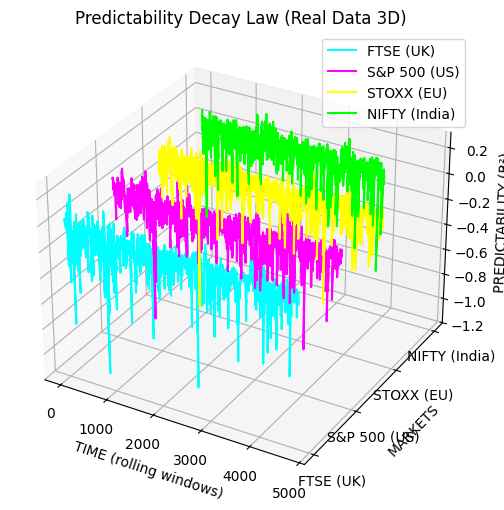

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')

markets_data = [
    results['predictability'].values,        # FTSE
    results_sp['predictability'].values,     # US
    results_eu['predictability'].values,     # Europe
    results_india['predictability'].values   # India
]

labels = ['FTSE (UK)', 'S&P 500 (US)', 'STOXX (EU)', 'NIFTY (India)']
colors = ['cyan', 'magenta', 'yellow', 'lime']

# Plot REAL data
for i, (data, color, label) in enumerate(zip(markets_data, colors, labels)):

    x = np.arange(len(data))   # TIME (real index)
    y = np.full_like(x, i)     # MARKET index
    z = data                  # REAL predictability values

    ax.plot(x, y, z, color=color, linewidth=1.5, label=label)

# Labels (important!)
ax.set_xlabel('TIME (rolling windows)')
ax.set_ylabel('MARKETS')
ax.set_zlabel('PREDICTABILITY (R²)')

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)

ax.set_title('Predictability Decay Law (Real Data 3D)')

ax.legend()

plt.show()

/tmp/ipykernel_3617/1065081499.py:74: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



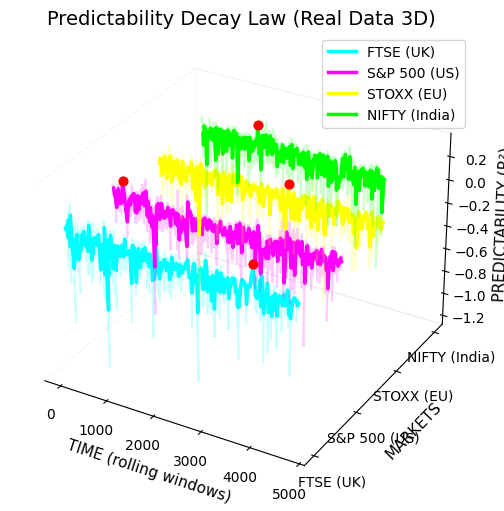

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D

# -------------------------------
# Step 1: Prepare your real data
# -------------------------------

markets_data_raw = [
    results['predictability'].values,        # FTSE
    results_sp['predictability'].values,     # S&P
    results_eu['predictability'].values,     # STOXX
    results_india['predictability'].values   # NIFTY
]

labels = ['FTSE (UK)', 'S&P 500 (US)', 'STOXX (EU)', 'NIFTY (India)']
colors = ['cyan', 'magenta', 'yellow', 'lime']

# -------------------------------
# Step 2: Create 3D plot
# -------------------------------

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')

# -------------------------------
# Step 3: Plot each market
# -------------------------------

for i, (data_raw, color, label) in enumerate(zip(markets_data_raw, colors, labels)):

    # REAL TIME
    x = np.arange(len(data_raw))
    y = np.full_like(x, i)

    # SMOOTHED DATA (this is key!)
    data_smooth = pd.Series(data_raw).rolling(20).mean()

    # Plot RAW (transparent - shows real fluctuations)
    ax.plot(x, y, data_raw, color=color, alpha=0.2)

    # Plot SMOOTH (main line - shows decay pattern clearly)
    ax.plot(x, y, data_smooth, color=color, linewidth=2.5, label=label)

    # Mark PEAK
    peak_idx = np.nanargmax(data_smooth)
    ax.scatter(peak_idx, i, data_smooth[peak_idx], color='red', s=40)

# -------------------------------
# Step 4: Labels (VERY IMPORTANT)
# -------------------------------

ax.set_xlabel('TIME (rolling windows)', fontsize=11)
ax.set_ylabel('MARKETS', fontsize=11)
ax.set_zlabel('PREDICTABILITY (R²)', fontsize=11)

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)

ax.set_title('Predictability Decay Law (Real Data 3D)', fontsize=14)

# -------------------------------
# Step 5: Clean style
# -------------------------------

ax.grid(False)

for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis.pane.fill = False

ax.legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_3617/1844958403.py:82: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



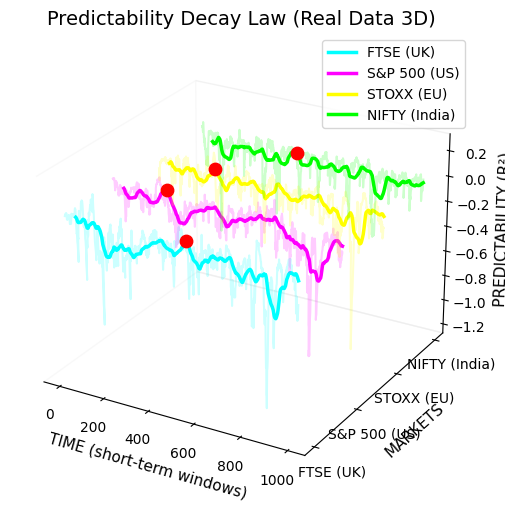

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D

# -------------------------------
# Step 1: Get real data
# -------------------------------

markets_data_raw = [
    results['predictability'].values,        # FTSE
    results_sp['predictability'].values,     # S&P
    results_eu['predictability'].values,     # STOXX
    results_india['predictability'].values   # NIFTY
]

labels = ['FTSE (UK)', 'S&P 500 (US)', 'STOXX (EU)', 'NIFTY (India)']
colors = ['cyan', 'magenta', 'yellow', 'lime']

# -------------------------------
# Step 2: Create figure
# -------------------------------

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')

# -------------------------------
# Step 3: Plot each market
# -------------------------------

window = 1000   # 👈 important (zoom into first 1000 points)

for i, (data_raw, color, label) in enumerate(zip(markets_data_raw, colors, labels)):

    # Limit to window (zoom)
    data_raw = data_raw[:window]

    # Time axis
    x = np.arange(len(data_raw))
    y = np.full_like(x, i)

    # Smooth data (VERY IMPORTANT)
    data_smooth = pd.Series(data_raw).rolling(50).mean()

    # Plot RAW data (transparent background)
    ax.plot(x, y, data_raw, color=color, alpha=0.2)

    # Plot SMOOTH data (main line)
    ax.plot(x, y, data_smooth, color=color, linewidth=2.5, label=label)

    # Mark PEAK
    peak_idx = np.nanargmax(data_smooth)
    ax.scatter(peak_idx, i, data_smooth.iloc[peak_idx], color='red', s=80)

# -------------------------------
# Step 4: Labels
# -------------------------------

ax.set_xlabel('TIME (short-term windows)', fontsize=11)
ax.set_ylabel('MARKETS', fontsize=11)
ax.set_zlabel('PREDICTABILITY (R²)', fontsize=11)

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)

ax.set_title('Predictability Decay Law (Real Data 3D)', fontsize=14)

# -------------------------------
# Step 5: Clean style
# -------------------------------

ax.grid(False)

for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis.pane.fill = False

# Better view angle
ax.view_init(elev=25, azim=-60)

ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D

# -------------------------------
# Step 1: Get real data
# -------------------------------

markets_data_raw = [
    results['predictability'].values,        # FTSE
    results_sp['predictability'].values,     # S&P
    results_eu['predictability'].values,     # STOXX
    results_india['predictability'].values   # NIFTY
]

labels = ['FTSE (UK)', 'S&P 500 (US)', 'STOXX (EU)', 'NIFTY (India)']
colors = ['cyan', 'magenta', 'yellow', 'lime']

# -------------------------------
# Step 2: Create figure
# -------------------------------

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')

# -------------------------------
# Step 3: Plot each market
# -------------------------------

window = 1000  # Zoom window

for i, (data_raw, color, label) in enumerate(zip(markets_data_raw, colors, labels)):

    # Limit to window
    data_raw = data_raw[:window]

    # Time axis
    x = np.arange(len(data_raw))
    y = np.full_like(x, i)

    # -------------------------------
    # Smooth data (fixed NaN issue)
    # -------------------------------
    data_smooth = pd.Series(data_raw).rolling(50, min_periods=1).mean()

    # -------------------------------
    # Plot RAW data (background noise)
    # -------------------------------
    ax.plot(x, y, data_raw, color=color, alpha=0.2)

    # -------------------------------
    # Plot SMOOTH data (main line)
    # -------------------------------
    ax.plot(x, y, data_smooth, color=color, linewidth=2.5, label=label)

    # -------------------------------
    # Confidence band (decay envelope)
    # -------------------------------
    std_dev = np.nanstd(data_raw)
    upper = data_smooth + std_dev
    lower = data_smooth - std_dev

    ax.plot(x, y, upper, color=color, alpha=0.15)
    ax.plot(x, y, lower, color=color, alpha=0.15)

    # -------------------------------
    # Find and mark PEAK
    # -------------------------------
    peak_idx = np.nanargmax(data_smooth.values)
    peak_val = data_smooth.iloc[peak_idx]

    ax.scatter(peak_idx, i, peak_val, color='red', s=80)

    # -------------------------------
    # Highlight DECAY phase
    # -------------------------------
    ax.plot(x[peak_idx:],
            np.full_like(x[peak_idx:], i),
            data_smooth.iloc[peak_idx:],
            color='white', linestyle='dashed', linewidth=2)

# -------------------------------
# Step 4: Labels and formatting
# -------------------------------

ax.set_xlabel('TIME (short-term windows)', fontsize=11)
ax.set_ylabel('MARKETS', fontsize=11)
ax.set_zlabel('PREDICTABILITY (R²)', fontsize=11)

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=10)

# Z-axis limits (stabilise visual scale)
ax.set_zlim(-1.2, 0.4)

# Improved academic title
ax.set_title('Cross-Market Predictability Decay in Financial Time Series', fontsize=14)

# -------------------------------
# Step 5: Clean style
# -------------------------------

ax.grid(False)

for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis.pane.fill = False

# Better viewing angle
ax.view_init(elev=25, azim=-60)

ax.legend()

# -------------------------------
# Step 6: Save high-quality image
# -------------------------------

plt.tight_layout()
plt.savefig("predictability_decay_3D.png", dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D

# -------------------------------
# Step 1: Data
# -------------------------------

markets_data_raw = [
    results['predictability'].values,
    results_sp['predictability'].values,
    results_eu['predictability'].values,
    results_india['predictability'].values
]

labels = ['FTSE (UK)', 'S&P 500 (US)', 'STOXX (EU)', 'NIFTY (India)']

# ✅ Professional muted colors (VERY IMPORTANT)
colors = ['#2C7BB6', '#D7191C', '#FDAE61', '#1A9641']

# -------------------------------
# Step 2: Figure (clean white)
# -------------------------------

plt.style.use('default')

fig = plt.figure(figsize=(10,6), facecolor='white')
ax = fig.add_subplot(111, projection='3d', facecolor='white')

# -------------------------------
# Step 3: Plot
# -------------------------------

window = 1000

for i, (data_raw, color, label) in enumerate(zip(markets_data_raw, colors, labels)):

    data_raw = data_raw[:window]

    x = np.arange(len(data_raw))
    y = np.full_like(x, i)

    # Smooth data
    data_smooth = pd.Series(data_raw).rolling(50, min_periods=1).mean()

    # ✅ Light raw data (very subtle)
    ax.plot(x, y, data_raw, color=color, alpha=0.10)

    # ✅ Main smooth line (clear + strong)
    ax.plot(x, y, data_smooth, color=color, linewidth=2.2, label=label)

    # ✅ Soft confidence band
    std_dev = np.nanstd(data_raw)
    upper = data_smooth + std_dev
    lower = data_smooth - std_dev

    ax.plot(x, y, upper, color=color, alpha=0.08)
    ax.plot(x, y, lower, color=color, alpha=0.08)

    # ✅ Peak point (clean black marker instead of red)
    peak_idx = np.nanargmax(data_smooth.values)
    peak_val = data_smooth.iloc[peak_idx]

    ax.scatter(peak_idx, i, peak_val, color='black', s=45, zorder=5)

    # ✅ Decay phase (subtle dashed)
    ax.plot(x[peak_idx:],
            np.full_like(x[peak_idx:], i),
            data_smooth.iloc[peak_idx:],
            color=color, linestyle='dashed', linewidth=1.6, alpha=0.9)

# -------------------------------
# Step 4: Labels (clean spacing)
# -------------------------------

ax.set_xlabel('Time (short-term windows)', fontsize=11, labelpad=12)

ax.set_ylabel('Markets', fontsize=11, labelpad=28)
ax.set_zlabel('Predictability (R²)', fontsize=11, labelpad=10)

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=10)

ax.tick_params(axis='y', pad=10)

# Push Y label outward
ax.yaxis._axinfo['label']['space_factor'] = 3.0

# Z limits
ax.set_zlim(-1.2, 0.4)

# ✅ Clean academic title
ax.set_title('Cross-Market Predictability Decay in Financial Time Series',
             fontsize=14, pad=18, weight='semibold')

# -------------------------------
# Step 5: Minimalist styling
# -------------------------------

ax.grid(False)

# Remove panes completely (clean white look)
for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis.pane.set_edgecolor('white')
    axis.pane.fill = False

# ✅ Softer axis lines
ax.xaxis.line.set_color('gray')
ax.yaxis.line.set_color('gray')
ax.zaxis.line.set_color('gray')

# ✅ Better 3D view
ax.view_init(elev=22, azim=-48)

# Legend (clean)
ax.legend(frameon=False, loc='upper right')

# -------------------------------
# Step 6: Save
# -------------------------------

plt.tight_layout()
plt.savefig("predictability_decay_beautiful.png",
            dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

/tmp/ipykernel_3617/575955485.py:116: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



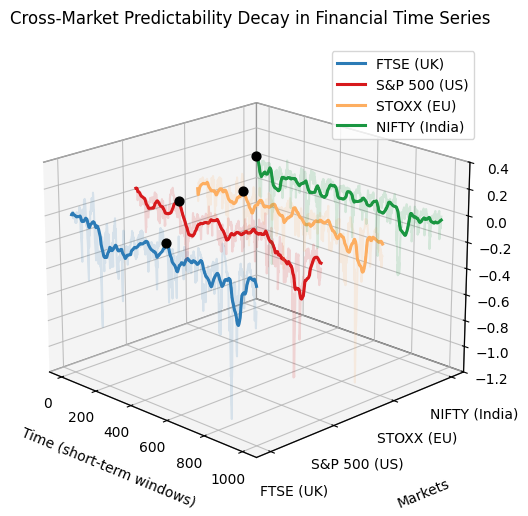

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D

# -------------------------------
# Data
# -------------------------------

markets_data_raw = [
    results['predictability'].values,
    results_sp['predictability'].values,
    results_eu['predictability'].values,
    results_india['predictability'].values
]

labels = ['FTSE (UK)', 'S&P 500 (US)', 'STOXX (EU)', 'NIFTY (India)']
colors = ['#2C7BB6', '#D7191C', '#FDAE61', '#1A9641']

# -------------------------------
# Figure
# -------------------------------

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')

# ✅ R-style grey cube walls
ax.xaxis.pane.set_facecolor((0.92, 0.92, 0.92, 1))
ax.yaxis.pane.set_facecolor((0.92, 0.92, 0.92, 1))
ax.zaxis.pane.set_facecolor((0.92, 0.92, 0.92, 1))

# ✅ Box edges visible (like R)
ax.xaxis.pane.set_edgecolor('black')
ax.yaxis.pane.set_edgecolor('black')
ax.zaxis.pane.set_edgecolor('black')

# -------------------------------
# Plot lines (YOUR ORIGINAL STYLE)
# -------------------------------

window = 1000

for i, (data_raw, color, label) in enumerate(zip(markets_data_raw, colors, labels)):

    data_raw = data_raw[:window]

    x = np.arange(len(data_raw))
    y = np.full_like(x, i)

    # Smooth
    data_smooth = pd.Series(data_raw).rolling(50, min_periods=1).mean()

    # Raw (faint)
    ax.plot(x, y, data_raw, color=color, alpha=0.15)

    # Smooth (main)
    ax.plot(x, y, data_smooth, color=color, linewidth=2.2, label=label)

    # Peak
    peak_idx = np.nanargmax(data_smooth.values)
    peak_val = data_smooth.iloc[peak_idx]
    ax.scatter(peak_idx, i, peak_val, color='black', s=40)

    # Decay phase
    ax.plot(x[peak_idx:],
            np.full_like(x[peak_idx:], i),
            data_smooth.iloc[peak_idx:],
            linestyle='dashed', color=color, linewidth=1.6)

# -------------------------------
# Labels
# -------------------------------

ax.set_xlabel('Time (short-term windows)', labelpad=10)
ax.set_ylabel('Markets', labelpad=25)
ax.set_zlabel('Predictability (R²)', labelpad=10)

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)

# Fix spacing
ax.tick_params(axis='y', pad=10)
ax.yaxis._axinfo['label']['space_factor'] = 3.0

# Limits
ax.set_zlim(-1.2, 0.4)

# Title
ax.set_title('Cross-Market Predictability Decay in Financial Time Series', pad=15)

# -------------------------------
# ✅ GRID (R-style lines inside box)
# -------------------------------

ax.grid(True)

# Make gridlines visible & clean
for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis._axinfo["grid"]['color'] = (0.7, 0.7, 0.7, 0.8)
    axis._axinfo["grid"]['linewidth'] = 0.8
    axis._axinfo["grid"]['linestyle'] = '-'

# -------------------------------
# View (important for cube look)
# -------------------------------

ax.view_init(elev=20, azim=-45)

# Legend
ax.legend()

# -------------------------------
# Save
# -------------------------------

plt.tight_layout()
plt.savefig("r_style_3d_lines.png", dpi=300, bbox_inches='tight')

plt.show()

/tmp/ipykernel_3617/575955485.py:116: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



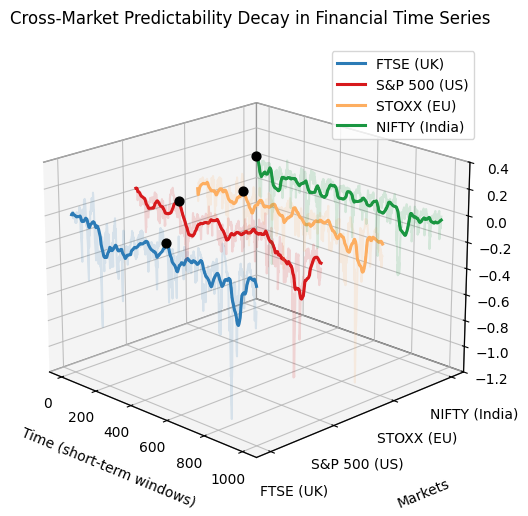

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D

# -------------------------------
# Data
# -------------------------------

markets_data_raw = [
    results['predictability'].values,
    results_sp['predictability'].values,
    results_eu['predictability'].values,
    results_india['predictability'].values
]

labels = ['FTSE (UK)', 'S&P 500 (US)', 'STOXX (EU)', 'NIFTY (India)']
colors = ['#2C7BB6', '#D7191C', '#FDAE61', '#1A9641']

# -------------------------------
# Figure
# -------------------------------

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')

# ✅ R-style grey cube walls
ax.xaxis.pane.set_facecolor((0.92, 0.92, 0.92, 1))
ax.yaxis.pane.set_facecolor((0.92, 0.92, 0.92, 1))
ax.zaxis.pane.set_facecolor((0.92, 0.92, 0.92, 1))

# ✅ Box edges visible (like R)
ax.xaxis.pane.set_edgecolor('black')
ax.yaxis.pane.set_edgecolor('black')
ax.zaxis.pane.set_edgecolor('black')

# -------------------------------
# Plot lines (YOUR ORIGINAL STYLE)
# -------------------------------

window = 1000

for i, (data_raw, color, label) in enumerate(zip(markets_data_raw, colors, labels)):

    data_raw = data_raw[:window]

    x = np.arange(len(data_raw))
    y = np.full_like(x, i)

    # Smooth
    data_smooth = pd.Series(data_raw).rolling(50, min_periods=1).mean()

    # Raw (faint)
    ax.plot(x, y, data_raw, color=color, alpha=0.15)

    # Smooth (main)
    ax.plot(x, y, data_smooth, color=color, linewidth=2.2, label=label)

    # Peak
    peak_idx = np.nanargmax(data_smooth.values)
    peak_val = data_smooth.iloc[peak_idx]
    ax.scatter(peak_idx, i, peak_val, color='black', s=40)

    # Decay phase
    ax.plot(x[peak_idx:],
            np.full_like(x[peak_idx:], i),
            data_smooth.iloc[peak_idx:],
            linestyle='dashed', color=color, linewidth=1.6)

# -------------------------------
# Labels
# -------------------------------

ax.set_xlabel('Time (short-term windows)', labelpad=10)
ax.set_ylabel('Markets', labelpad=25)
ax.set_zlabel('Predictability (R²)', labelpad=10)

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)

# Fix spacing
ax.tick_params(axis='y', pad=10)
ax.yaxis._axinfo['label']['space_factor'] = 3.0

# Limits
ax.set_zlim(-1.2, 0.4)

# Title
ax.set_title('Cross-Market Predictability Decay in Financial Time Series', pad=15)

# -------------------------------
# ✅ GRID (R-style lines inside box)
# -------------------------------

ax.grid(True)

# Make gridlines visible & clean
for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis._axinfo["grid"]['color'] = (0.7, 0.7, 0.7, 0.8)
    axis._axinfo["grid"]['linewidth'] = 0.8
    axis._axinfo["grid"]['linestyle'] = '-'

# -------------------------------
# View (important for cube look)
# -------------------------------

ax.view_init(elev=20, azim=-45)

# Legend
ax.legend()

# -------------------------------
# Save
# -------------------------------

plt.tight_layout()
plt.savefig("r_style_3d_lines.png", dpi=300, bbox_inches='tight')

plt.show()

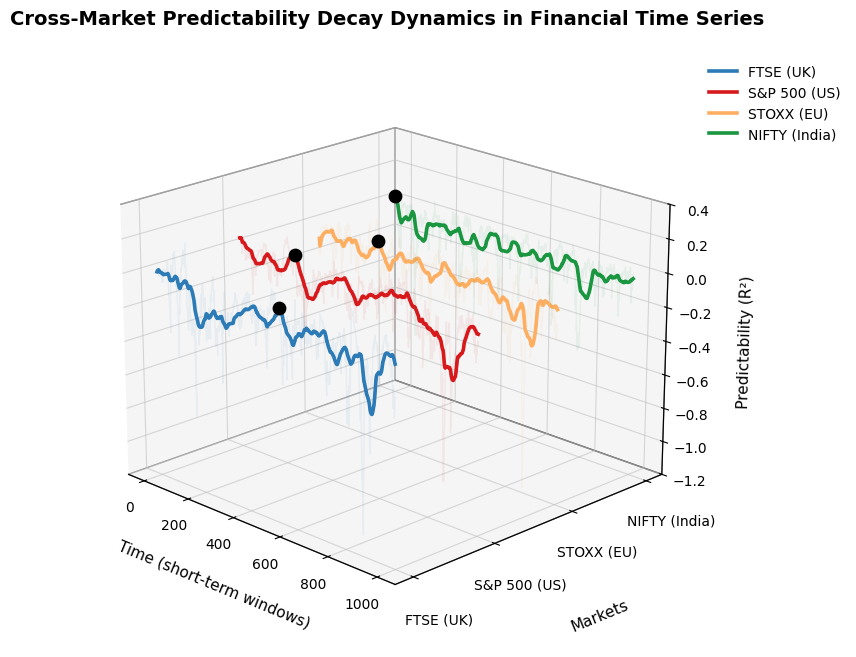

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D

# -------------------------------
# Data
# -------------------------------

markets_data_raw = [
    results['predictability'].values,
    results_sp['predictability'].values,
    results_eu['predictability'].values,
    results_india['predictability'].values
]

labels = ['FTSE (UK)', 'S&P 500 (US)', 'STOXX (EU)', 'NIFTY (India)']
colors = ['#2C7BB6', '#D7191C', '#FDAE61', '#1A9641']

# -------------------------------
# Figure (bigger + balanced)
# -------------------------------

fig = plt.figure(figsize=(12,7))
ax = fig.add_subplot(111, projection='3d')

# -------------------------------
# ✅ R-style cube (refined)
# -------------------------------

cube_color = (0.93, 0.93, 0.93, 1)

ax.xaxis.pane.set_facecolor(cube_color)
ax.yaxis.pane.set_facecolor(cube_color)
ax.zaxis.pane.set_facecolor(cube_color)

ax.xaxis.pane.set_edgecolor('black')
ax.yaxis.pane.set_edgecolor('black')
ax.zaxis.pane.set_edgecolor('black')

# -------------------------------
# Plot
# -------------------------------

window = 1000

for i, (data_raw, color, label) in enumerate(zip(markets_data_raw, colors, labels)):

    data_raw = data_raw[:window]

    x = np.arange(len(data_raw))
    y = np.full_like(x, i)

    # ✅ Smooth data
    data_smooth = pd.Series(data_raw).rolling(50, min_periods=1).mean()

    # ✅ Raw noise (VERY subtle)
    ax.plot(x, y, data_raw, color=color, alpha=0.07, linewidth=1)

    # ✅ Main signal (clear + dominant)
    ax.plot(x, y, data_smooth, color=color, linewidth=2.6, label=label)

    # ✅ Peak marker (stronger)
    peak_idx = np.nanargmax(data_smooth.values)
    peak_val = data_smooth.iloc[peak_idx]
    ax.scatter(peak_idx, i, peak_val, color='black', s=80, zorder=5)

    # ✅ Decay phase (refined)
    ax.plot(x[peak_idx:],
            np.full_like(x[peak_idx:], i),
            data_smooth.iloc[peak_idx:],
            linestyle='dashed', color=color, linewidth=1.8, alpha=0.9)

# -------------------------------
# Labels (clean spacing)
# -------------------------------

ax.set_xlabel('Time (short-term windows)', fontsize=11, labelpad=12)
ax.set_ylabel('Markets', fontsize=11, labelpad=30)
ax.set_zlabel('Predictability (R²)', fontsize=11, labelpad=12)

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=10)

# ✅ Push labels away (important)
ax.tick_params(axis='y', pad=12)
ax.yaxis._axinfo['label']['space_factor'] = 3.2

# -------------------------------
# Limits
# -------------------------------

ax.set_zlim(-1.2, 0.4)

# -------------------------------
# Title (refined academic tone)
# -------------------------------

ax.set_title('Cross-Market Predictability Decay Dynamics in Financial Time Series',
             fontsize=14, pad=20, weight='semibold')

# -------------------------------
# ✅ Grid styling (clean + professional)
# -------------------------------

ax.grid(True)

for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis._axinfo["grid"]['color'] = (0.75, 0.75, 0.75, 0.6)
    axis._axinfo["grid"]['linewidth'] = 0.8
    axis._axinfo["grid"]['linestyle'] = '-'

# -------------------------------
# View angle (balanced perspective)
# -------------------------------

ax.view_init(elev=20, azim=-45)

# -------------------------------
# ✅ Move legend OUTSIDE (fix crowding)
# -------------------------------

ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), frameon=False)

# -------------------------------
# ✅ FIX layout WARNING (key change)
# -------------------------------

plt.subplots_adjust(left=0.05, right=0.78, top=0.9, bottom=0.05)

# -------------------------------
# Save (publication quality)
# -------------------------------

plt.savefig("top_tier_predictability_3D.png", dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# -------------------------------
# Sample data (replace with yours)
# -------------------------------

# Example: using your predictability idea
markets_data = [
    results['predictability'].values[:100],
    results_sp['predictability'].values[:100],
    results_eu['predictability'].values[:100],
    results_india['predictability'].values[:100]
]

labels = ['FTSE', 'S&P 500', 'STOXX', 'NIFTY']

# -------------------------------
# Build 3D scatter
# -------------------------------

fig = go.Figure()

for i, data in enumerate(markets_data):

    x = np.arange(len(data))   # time
    y = np.full_like(x, i)     # market index
    z = data                   # predictability

    fig.add_trace(go.Scatter3d(
        x=x,
        y=y,
        z=z,
        mode='markers',
        marker=dict(
            size=4,
            symbol='circle',
            opacity=0.8
        ),
        name=labels[i]
    ))

# -------------------------------
# Layout (R-style cube)
# -------------------------------

fig.update_layout(
    title='3D Predictability Structure (R-style Visualization)',

    scene=dict(
        xaxis=dict(
            title='Time',
            backgroundcolor="rgb(240,240,240)",  # light wall
            gridcolor="white",
            showbackground=True
        ),
        yaxis=dict(
            title='Markets',
            tickvals=list(range(len(labels))),
            ticktext=labels,
            backgroundcolor="rgb(240,240,240)",
            gridcolor="white",
            showbackground=True
        ),
        zaxis=dict(
            title='Predictability (R²)',
            backgroundcolor="rgb(240,240,240)",
            gridcolor="white",
            showbackground=True
        ),
    ),

    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

In [ ]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# -------------------------------
# Data
# -------------------------------

markets_data = [
    results['predictability'].values[:300],
    results_sp['predictability'].values[:300],
    results_eu['predictability'].values[:300],
    results_india['predictability'].values[:300]
]

labels = ['FTSE (UK)', 'S&P 500 (US)', 'STOXX (EU)', 'NIFTY (India)']

# ✅ Professional colors
colors = ['#2C7BB6', '#D7191C', '#FDAE61', '#1A9641']

fig = go.Figure()

# -------------------------------
# Build LINES instead of dots ✅
# -------------------------------

for i, (data, color, label) in enumerate(zip(markets_data, colors, labels)):

    x = np.arange(len(data))
    y = np.full(len(data), i)

    # ✅ Smooth data
    smooth = pd.Series(data).rolling(30, min_periods=1).mean()

    fig.add_trace(go.Scatter3d(
        x=x,
        y=y,
        z=smooth,
        mode='lines',   # ✅ THIS FIXES YOUR MAIN ISSUE
        line=dict(
            color=color,
            width=5
        ),
        name=label
    ))

# -------------------------------
# Layout (BEAUTIFUL cube)
# -------------------------------

fig.update_layout(
    title='Interactive Predictability Decay (3D View)',

    scene=dict(

        xaxis=dict(
            title='Time',
            backgroundcolor="rgb(235,235,235)",
            gridcolor="white",
            showbackground=True,
            zerolinecolor="gray"
        ),

        yaxis=dict(
            title='Markets',
            tickvals=list(range(len(labels))),
            ticktext=labels,
            backgroundcolor="rgb(235,235,235)",
            gridcolor="white",
            showbackground=True
        ),

        zaxis=dict(
            title='Predictability (R²)',
            backgroundcolor="rgb(235,235,235)",
            gridcolor="white",
            showbackground=True
        ),
    ),

    # ✅ cleaner legend
    legend=dict(
        bgcolor='rgba(255,255,255,0.7)'
    ),

    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

In [ ]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# -------------------------------
# Step 1: Data
ability'].values[:300],        # FTSE
    results_sp['predictability'].values[:300],     # S&P
    results_eu['predictability'].values[:300],     # STOXX
    results_india['predictability'].values[:300]   # NIFTY
]

labels = ['FTSE (UK)', 'S&P 500 (US)', 'STOXX (EU)', 'NIFTY (India)']

# ✅ Professional colours
colors = ['#2C7BB6', '#D7191C', '#FDAE61', '#1A9641']

# -------------------------------
# Step 2: Create Figure
# -------------------------------

fig = go.Figure()

# -------------------------------
# Step 3: Plot LINES (fixed visibility)
# -------------------------------

for i, (data, color, label) in enumerate(zip(markets_data, colors, labels)):

    x = np.arange(len(data))

    # ✅ FIX: Spread lines away from cube edges
    y = np.full(len(data), i * 2)

    # ✅ Smooth data
    smooth = pd.Series(data).rolling(30, min_periods=1).mean()

    fig.add_trace(go.Scatter3d(
        x=x,
        y=y,
        z=smooth,
        mode='lines',
        line=dict(color=color, width=6),
        name=label
    ))

# -------------------------------
# Step 4: Layout (R-style cube)
# -------------------------------

fig.update_layout(
    title='Interactive Predictability Decay (3D View)',

    scene=dict(
        xaxis=dict(
            title='Time',
            backgroundcolor="rgb(230,230,230)",
            gridcolor="white",
            showbackground=True
        ),

        yaxis=dict(
            title='Markets',
            tickvals=[0, 2, 4, 6],     # ✅ match spacing
            ticktext=labels,
            backgroundcolor="rgb(230,230,230)",
            gridcolor="white",
            showbackground=True
        ),

        zaxis=dict(
            title='Predictability (R²)',
            backgroundcolor="rgb(230,230,230)",
            gridcolor="white",
            showbackground=True
        ),

        # ✅ Better camera angle (FTSE fully visible)
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=0.9)
        )
    ),

    legend=dict(
        bgcolor='rgba(255,255,255,0.7)'
    ),

    margin=dict(l=0, r=0, b=0, t=40)
)

# -------------------------------
# Step 5: Show plot
# -------------------------------

fig.show()

# -------------------------------
# Step 6: Save & Download
# -------------------------------

# Save as interactive HTML
fig.write_html("predictability_3D_interactive.html")

# Download in Colab
from google.colab import files
files.download("predictability_3D_interactive.html")

IndentationError: unindent does not match any outer indentation level (<tokenize>, line 45)